# Fuzzy MCDA Methods under VISTA

This notebook explores how **fuzzy MCDA methods** behave under the VISTA visualization framework.

VISTA sweeps a test alternative across a 2-D criteria grid and classifies each point by its
relation (Better / Worse / Indifferent / Incomparable) to a fixed reference alternative.
Before evaluation, each crisp grid point is **fuzzified** into a triangular fuzzy number
parametrised by `spread` (support half-width) and `skew` (asymmetry).

We use this protocol to:
1. **Validate** fuzzy wrappers against their crisp counterparts (spread → 0).
2. **Visualise** how increasing fuzzification uncertainty reshapes decision boundaries.
3. **Compare** four fuzzy methods side-by-side: TOPSIS, VIKOR, MOORA, WASPAS.

## 1 · Introduction & Setup

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from mcda_vista import (
    generate_vista,
    plot_vista,
    plot_vista_grid,
    plot_vista_comparison,
    Relation,
)
from mcda_vista.fuzzy_utils import (
    fuzzy_topsis,
    fuzzy_vikor,
    fuzzy_moora,
    fuzzy_waspas,
)

## 2 · Baseline — Crisp TOPSIS vs Fuzzy TOPSIS (spread = 0)

When `spread=0` every triangular fuzzy number degenerates to a crisp value, so the fuzzy
wrapper should reproduce the crisp TOPSIS result exactly. This serves as a **sanity check**
for the fuzzification pipeline.

In [2]:
result_crisp = generate_vista("topsis", resolution=51, delta=0.10, progress=True)
result_fuzzy0 = generate_vista(fuzzy_topsis, resolution=51, spread=0.0, delta=0.10, progress=True)

D:\Praca\Uczelnia\Praca naukowa\Github\mcda-vista\src\mcda_vista\methods\_patches.py:383: UserWarning: Could not detect pyDecision version; VISTA patches may not apply correctly.
  apply_patches()


VISTA (topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (topsis):  73%|███████▎  | 1890/2601 [00:00<00:00, 18266.36pt/s]

VISTA (topsis): 100%|██████████| 2601/2601 [00:00<00:00, 15807.27pt/s]

VISTA (fuzzy_topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (fuzzy_topsis):  23%|██▎       | 594/2601 [00:00<00:00, 5896.63pt/s]

VISTA (fuzzy_topsis):  67%|██████▋   | 1751/2601 [00:00<00:00, 8956.31pt/s]

VISTA (fuzzy_topsis): 100%|██████████| 2601/2601 [00:00<00:00, 8519.72pt/s]

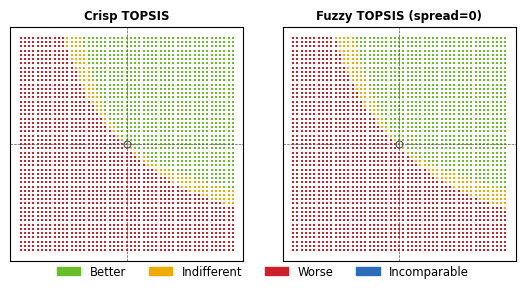

In [3]:
result_crisp.method_name = "Crisp TOPSIS"
result_fuzzy0.method_name = "Fuzzy TOPSIS (spread=0)"

plot_vista_comparison([result_crisp, result_fuzzy0])
plt.show()

**Observation:** With `spread=0` the fuzzy wrapper collapses to the crisp case — the two
maps should be visually identical, confirming that the fuzzification layer is correctly
implemented.

## 3 · Effect of Spread on Fuzzy TOPSIS

We now sweep the `spread` parameter from 0 (crisp) to 0.30 (wide uncertainty) and observe
how the VISTA decision boundaries evolve.

In [4]:
spreads = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]

spread_results = []
for s in spreads:
    r = generate_vista(fuzzy_topsis, resolution=51, spread=s, delta=0.10, progress=True)
    r.method_name = f"spread={s}"
    spread_results.append(r)

VISTA (fuzzy_topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (fuzzy_topsis):  41%|████      | 1061/2601 [00:00<00:00, 10574.86pt/s]

VISTA (fuzzy_topsis):  91%|█████████▏| 2374/2601 [00:00<00:00, 12066.95pt/s]

VISTA (fuzzy_topsis): 100%|██████████| 2601/2601 [00:00<00:00, 11979.36pt/s]

VISTA (fuzzy_topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

...

VISTA (fuzzy_topsis): 100%|██████████| 2601/2601 [00:00<00:00, 12438.06pt/s]

VISTA (fuzzy_topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (fuzzy_topsis):  37%|███▋      | 971/2601 [00:00<00:00, 9685.81pt/s]

VISTA (fuzzy_topsis):  80%|███████▉  | 2079/2601 [00:00<00:00, 10424.22pt/s]

VISTA (fuzzy_topsis): 100%|██████████| 2601/2601 [00:00<00:00, 9686.62pt/s] 

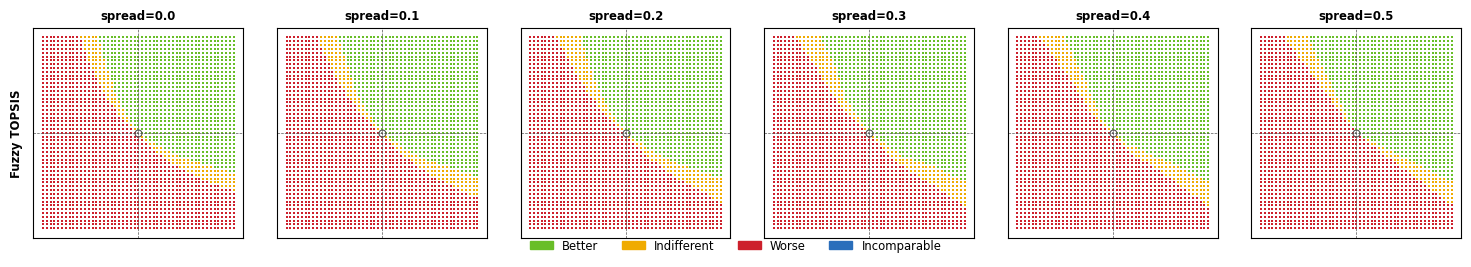

In [5]:
plot_vista_grid(
    [spread_results],
    row_labels=["Fuzzy TOPSIS"],
    col_labels=[f"spread={s}" for s in spreads],
)
plt.show()

**Observations:**
- At small spreads the map closely resembles the crisp baseline.
- As `spread` increases, the *Indifferent* region around the diagonal typically grows,
  reflecting the increasing overlap of fuzzy score distributions.
- Very large spreads may blur the Better/Worse boundary further or introduce
  Incomparable regions where the method can no longer discriminate.

## 4 · Effect of Skew (Asymmetric Fuzzy Numbers)

Fixing `spread=0.30` we vary `skew` in {−1.0, −0.5, 0.0, 0.5, 1.0}. Negative skew shifts the
triangle support to the left (pessimistic), positive skew to the right (optimistic).

In [6]:
skews = [-1.0, -0.5, 0.0, 0.5, 1.0]

skew_results = []
for sk in skews:
    r = generate_vista(
        fuzzy_topsis, resolution=51, spread=0.30, skew=sk, delta=0.10, progress=True
    )
    r.method_name = f"skew={sk}"
    skew_results.append(r)

VISTA (fuzzy_topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (fuzzy_topsis):  45%|████▍     | 1162/2601 [00:00<00:00, 11545.06pt/s]

VISTA (fuzzy_topsis):  93%|█████████▎| 2419/2601 [00:00<00:00, 12125.25pt/s]

VISTA (fuzzy_topsis): 100%|██████████| 2601/2601 [00:00<00:00, 11871.54pt/s]

VISTA (fuzzy_topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

...

VISTA (fuzzy_topsis): 100%|██████████| 2601/2601 [00:00<00:00, 8699.68pt/s]

VISTA (fuzzy_topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (fuzzy_topsis):  47%|████▋     | 1229/2601 [00:00<00:00, 12125.37pt/s]

VISTA (fuzzy_topsis):  94%|█████████▍| 2442/2601 [00:00<00:00, 11610.04pt/s]

VISTA (fuzzy_topsis): 100%|██████████| 2601/2601 [00:00<00:00, 11672.59pt/s]

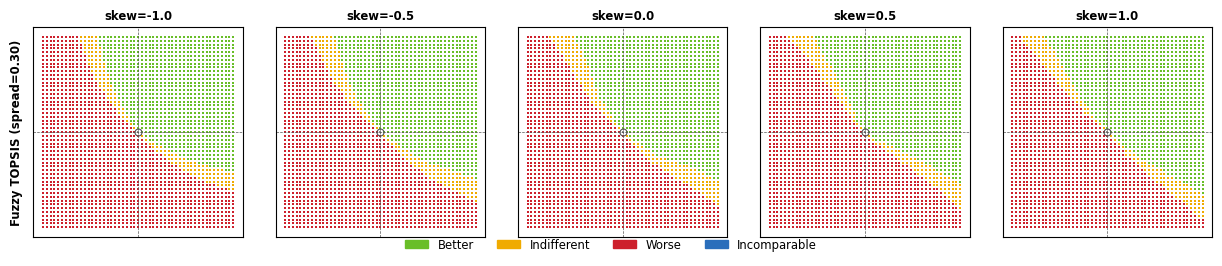

In [7]:
plot_vista_grid(
    [skew_results],
    row_labels=["Fuzzy TOPSIS (spread=0.30)"],
    col_labels=[f"skew={sk}" for sk in skews],
)
plt.show()

**Observations:**
- Symmetric fuzzy numbers (`skew=0`) produce balanced decision regions.
- Negative skew (pessimistic) tends to enlarge the *Worse* region — the decision-maker
  underestimates the test alternative's performance.
- Positive skew (optimistic) has the opposite effect, expanding the *Better* region.

## 5 · Cross-Method Comparison

We compare all four fuzzy wrappers at `spread=0.10`, `delta=0.10`.

> **Note:** Fuzzy VIKOR may produce a few ERROR points at degenerate grid positions
> where the 2-alternative normalisation breaks down — this is expected.

In [8]:
methods = [
    (fuzzy_topsis, "Fuzzy TOPSIS"),
    (fuzzy_vikor, "Fuzzy VIKOR"),
    (fuzzy_moora, "Fuzzy MOORA"),
    (fuzzy_waspas, "Fuzzy WASPAS"),
]

method_results = []
for fn, name in methods:
    r = generate_vista(fn, resolution=51, spread=0.30, delta=0.10, progress=True)
    r.method_name = name
    method_results.append(r)

VISTA (fuzzy_topsis):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (fuzzy_topsis):  45%|████▌     | 1180/2601 [00:00<00:00, 11231.13pt/s]

VISTA (fuzzy_topsis):  89%|████████▊ | 2304/2601 [00:00<00:00, 9335.56pt/s] 

VISTA (fuzzy_topsis): 100%|██████████| 2601/2601 [00:00<00:00, 9315.28pt/s]

VISTA (fuzzy_vikor):   0%|          | 0/2601 [00:00<?, ?pt/s]

...

VISTA (fuzzy_moora): 100%|██████████| 2601/2601 [00:00<00:00, 7073.95pt/s]

VISTA (fuzzy_waspas):   0%|          | 0/2601 [00:00<?, ?pt/s]

VISTA (fuzzy_waspas):  39%|███▉      | 1008/2601 [00:00<00:00, 9062.04pt/s]

VISTA (fuzzy_waspas):  93%|█████████▎| 2406/2601 [00:00<00:00, 11174.95pt/s]

VISTA (fuzzy_waspas): 100%|██████████| 2601/2601 [00:00<00:00, 11736.71pt/s]

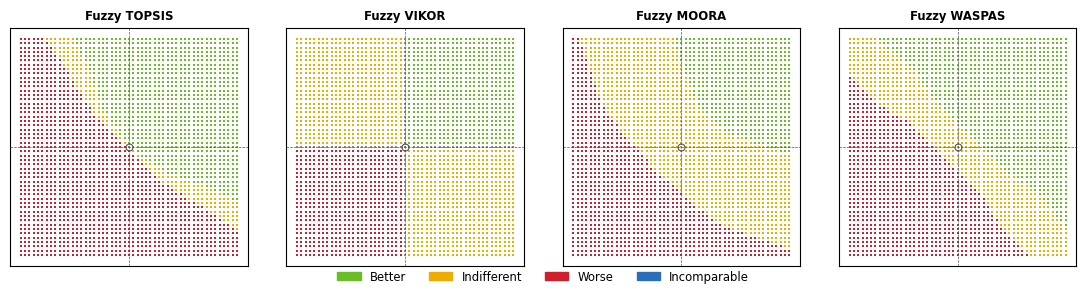

In [9]:
plot_vista_comparison(method_results, ncols=4)
plt.show()

**Observations:**
- All four methods broadly agree on the Better/Worse split along the diagonal.
- Differences appear in the shape and extent of the Indifferent/Incomparable zones:
  - *Fuzzy TOPSIS* and *Fuzzy WASPAS* tend to produce cleaner boundaries.
  - *Fuzzy VIKOR* may show artefacts at extreme corners due to normalisation.
  - *Fuzzy MOORA* can exhibit wider Indifferent bands.

## 6 · Summary

The table below counts the number of grid points classified into each relation category
across the key configurations explored above.

In [10]:
# Collect all results we want to summarise
summary_results = [
    result_crisp,
    result_fuzzy0,
    *spread_results,
    *skew_results,
    *method_results,
]

# Relation labels in display order
relation_labels = ["BETTER", "WORSE", "INDIFFERENT", "INCOMPARABLE", "ERROR"]

# Header
header = f"{'Configuration':<35s}" + "".join(f"{lbl:>15s}" for lbl in relation_labels)
print(header)
print("-" * len(header))

for r in summary_results:
    unique, counts = np.unique(r.relations, return_counts=True)
    count_map = dict(zip(unique, counts))
    row = f"{r.method_name:<35s}"
    for lbl in relation_labels:
        rel = getattr(Relation, lbl, None)
        row += f"{count_map.get(rel, 0):>15d}"
    print(row)

Configuration                               BETTER          WORSE    INDIFFERENT   INCOMPARABLE          ERROR
--------------------------------------------------------------------------------------------------------------
Crisp TOPSIS                                   983           1477            140              0              1
Fuzzy TOPSIS (spread=0)                        971           1467            162              0              1
spread=0.0                                     971           1467            162              0              1
spread=0.1                                     999           1429            172              0              1
spread=0.2                                    1007           1407            186              0              1
spread=0.3                                    1011           1395            194              0              1
spread=0.4                                     999           1419            182              0              1
s

### Key Takeaways

1. **Wrapper validation:** Fuzzy methods with `spread=0` reproduce the crisp baseline,
   confirming correctness of the fuzzification layer.
2. **Spread effect:** Increasing `spread` widens the Indifferent zone as fuzzy score
   distributions overlap more — a natural consequence of greater input uncertainty.
3. **Skew effect:** Asymmetric triangular numbers shift the Better/Worse balance,
   reflecting optimistic or pessimistic modelling assumptions.
4. **Method differences:** While all four fuzzy methods share the same broad structure,
   their boundary shapes and Indifferent/Incomparable extents differ — VISTA makes
   these differences immediately visible.